# Notebook 16 — Robust Semantic Boundary Leverage and causal score validation

**Purpose.** Compute SABER's directed, alert-costed channel importance and test
whether it predicts the actual semantic harm caused by removing individual
channels better than magnitude, Taylor, Fisher, and random rankings.

This is the **G1 go/no-go experiment**. Do not begin the full SABER training
stack if R-SBL does not win on the prespecified harm metrics.

**Primary harm endpoints**

1. Action-Weighted Boundary Inversion Rate (AWBIR)
2. Hierarchical Semantic Risk (HSR)
3. Fine-type macro-F1 loss
4. Family macro-F1 loss

**Outputs**

- cost-profile-specific SBL tables and robust R-SBL
- resumable single-channel ablation table
- rank-correlation and top-k harm retrieval report
- `G1_score_gate.json`

In [1]:
# Colab/repository bootstrap
from pathlib import Path
import os, sys, json, subprocess, platform

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

# Override with %env SABER_REPO=/your/path if your repository is elsewhere.
candidates = [
    os.environ.get("SABER_REPO"),
    "/content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression",
    str(Path.cwd()),
]
REPO = None
for candidate in candidates:
    if not candidate:
        continue
    p = Path(candidate).expanduser()
    if (p / "src").is_dir() and (p / "config").is_dir():
        REPO = p.resolve()
        break
if REPO is None:
    raise FileNotFoundError(
        "Repository not found. Set SABER_REPO or edit the candidate path."
    )
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

print("Repository:", REPO)
print("Python:", sys.version.split()[0], "| Platform:", platform.platform())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repository: /content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression
Python: 3.13.15 | Platform: Linux-6.6.122+-x86_64-with-glibc2.35


In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
import os
print(os.path.exists("/content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression/src/saber/adapters.py"))

Mounted at /content/drive
True


In [4]:
import os, subprocess, sys
os.chdir("/content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression")
print(open("requirements-saber.txt").read())
r = subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements-saber.txt"],
                   capture_output=True, text=True)
print(r.stdout[-1500:])
print("STDERR:", r.stderr[-1500:])

# Additional dependencies for SABER-IDS starter notebooks
# Install after the original repository requirements.
networkx>=3.2
pyyaml>=6
scipy>=1.10
scikit-learn>=1.3
pandas>=2.0
matplotlib>=3.7
nbformat>=5.9
pytest>=8
# Optional for later dependency-aware surgery on deeper architectures:
# torch-pruning>=1.5,<2

: iniconfig>=1 in /usr/local/lib/python3.13/dist-packages (from pytest>=8->-r requirements-saber.txt (line 10)) (2.3.0)

STDERR: 


In [5]:
import yaml
from src.saber.adapters import SaberRepo

repo = SaberRepo.discover(REPO)
with open(REPO / "config" / "saber.yaml", "r", encoding="utf-8") as handle:
    SABER_CFG = yaml.safe_load(handle)

OUTPUT_ROOT = repo.output_root
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print("SABER output root:", OUTPUT_ROOT)
print("Config branch:", SABER_CFG["project"]["branch"])

SABER output root: /content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression/results/saber
Config branch: saber-ids-method


In [6]:
from src.saber.bridge_ciciot import load_bridge
TRAIN_LOADER, VAL_LOADER, TEST_LOADER, MODEL, CLASS_NAMES = load_bridge()
print('bridge OK:', len(CLASS_NAMES), 'classes')

bridge OK: 34 classes


In [7]:
# Repository bridge: auto-discovery first, explicit override second.
#
# If auto-discovery fails, set these objects using the same loader/model
# construction cells from the completed Computer Networks notebooks:
#   TRAIN_LOADER = ...
#   VAL_LOADER = ...
#   TEST_LOADER = ...
#   MODEL = ...
#   CLASS_NAMES = [...]
#
# MODEL must be the uncompressed CNN1D anchor and loaders must use the frozen
# train/validation/test split.

import torch
from src.saber.adapters import (
    auto_discover_loaders,
    auto_build_cnn,
    discover_anchor_checkpoint,
    infer_class_names_from_results,
    unpack_batch,
)

TRAIN_LOADER = globals().get("TRAIN_LOADER")
VAL_LOADER = globals().get("VAL_LOADER")
TEST_LOADER = globals().get("TEST_LOADER")
MODEL = globals().get("MODEL")
CLASS_NAMES = globals().get("CLASS_NAMES")

if any(obj is None for obj in (TRAIN_LOADER, VAL_LOADER, TEST_LOADER)):
    TRAIN_LOADER, VAL_LOADER, TEST_LOADER, _DATA_BUNDLE = auto_discover_loaders(repo)

first_batch = next(iter(VAL_LOADER))
x0, y0, env0 = unpack_batch(first_batch)
raw_example = x0[: min(8, len(x0))].float()

if CLASS_NAMES is None:
    CLASS_NAMES = infer_class_names_from_results(repo)

if MODEL is None:
    checkpoint = discover_anchor_checkpoint(repo)
    MODEL, MODEL_FACTORY_ERRORS = auto_build_cnn(
        n_features=int(x0.shape[-1]),
        n_classes=len(CLASS_NAMES),
        checkpoint=checkpoint,
    )
    print("Loaded checkpoint:", checkpoint)
    if MODEL_FACTORY_ERRORS:
        print("Model factory attempts that were skipped:", MODEL_FACTORY_ERRORS)

# Infer whether the historical CNN expects [B,F] and unsqueezes internally or
# expects an explicit [B,1,F] tensor. This decision is frozen for the notebook.
MODEL_INPUT_MODE = None
probe_out = None
candidate_inputs = [("raw", raw_example)]
if raw_example.ndim == 2:
    candidate_inputs.append(("unsqueeze_channel", raw_example.unsqueeze(1)))
errors = {}
MODEL.eval()
for mode, candidate in candidate_inputs:
    try:
        with torch.no_grad():
            probe_out = MODEL(candidate)
        MODEL_INPUT_MODE = mode
        EXAMPLE_INPUT = candidate
        break
    except Exception as exc:
        errors[mode] = repr(exc)

if MODEL_INPUT_MODE is None:
    raise RuntimeError(
        "Could not infer the CNN input convention. Set EXAMPLE_INPUT and "
        "MODEL_INPUT manually. Attempts: " + json.dumps(errors, indent=2)
    )

def MODEL_INPUT(x):
    if MODEL_INPUT_MODE == "unsqueeze_channel" and x.ndim == 2:
        return x.unsqueeze(1)
    return x

if probe_out.shape[1] != len(CLASS_NAMES):
    raise RuntimeError(
        f"Model outputs {probe_out.shape[1]} classes but CLASS_NAMES has "
        f"{len(CLASS_NAMES)} entries. Supply the exact label-encoder order."
    )

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL = MODEL.to(DEVICE)
EXAMPLE_INPUT = EXAMPLE_INPUT.to(DEVICE)
print("Device:", DEVICE)
print("Model:", type(MODEL).__name__)
print("Classes:", len(CLASS_NAMES))
print("Input convention:", MODEL_INPUT_MODE, tuple(EXAMPLE_INPUT.shape))

Device: cuda
Model: CNN1D
Classes: 34
Input convention: raw (8, 41)


## 1. Load the frozen graph and baseline group scores

In [8]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path

from src.saber.taxonomy import ciciot2023_taxonomy, DEFAULT_COST_PROFILES
from src.saber.risk_graph import aggregate_robust_edge_weights
from src.saber.leverage import (
    semantic_boundary_leverage,
    robust_profile_aggregation,
    merge_score_tables,
    validate_score_against_harm,
)

GRAPH_DIR = OUTPUT_ROOT / "14_risk_graph"
BASELINE_DIR = OUTPUT_ROOT / "15_baselines"
OUT = OUTPUT_ROOT / "16_score_validation"
OUT.mkdir(parents=True, exist_ok=True)

taxonomy = ciciot2023_taxonomy(CLASS_NAMES)
groups = pd.read_csv(BASELINE_DIR / "prunable_groups.csv")
baseline_scores = pd.read_csv(BASELINE_DIR / "group_baseline_scores.csv")
edges_by_profile = pd.read_csv(GRAPH_DIR / "asvg_edges_by_cost_profile.csv")
robust_graph = pd.read_csv(GRAPH_DIR / "asvg_edges_robust.csv")

assert set(groups["group_id"]) == set(baseline_scores["group_id"])
assert np.isclose(robust_graph["robust_weight"].sum(), 1.0)
print("Groups:", len(groups), "| Robust edges:", len(robust_graph))

Groups: 192 | Robust edges: 105


## 2. Compute SBL under each cost profile and robustly aggregate

A backward pass is made per directed edge on a capped, class-balanced validation
subset. The cap is a compute control; repeat later at multiple caps to document
score stability before confirmatory experiments.

In [9]:
profile_score_tables = {}
edge_contribution_tables = []

for profile_name in DEFAULT_COST_PROFILES:
    profile_edges = edges_by_profile[
        edges_by_profile["cost_profile"] == profile_name
    ].copy()
    table, edge_table = semantic_boundary_leverage(
        MODEL,
        VAL_LOADER,
        groups,
        profile_edges,
        device=DEVICE,
        max_samples_per_class=int(
            SABER_CFG["score_validation"]["max_samples_per_source_class"]
        ),
        edge_weight_column="normalized_weight",
        normalize_by_group_size=float(
            SABER_CFG["score_validation"]["group_size_alpha"]
        ),
        normalize_by_flops=float(SABER_CFG["score_validation"]["flops_beta"]),
        input_transform=MODEL_INPUT,
    )
    table["cost_profile"] = profile_name
    edge_table["cost_profile"] = profile_name
    profile_score_tables[profile_name] = table
    edge_contribution_tables.append(edge_table)
    table.to_csv(OUT / f"sbl_scores_{profile_name}.csv", index=False)

robust_scores = robust_profile_aggregation(
    profile_score_tables,
    score_column="sbl",
    method="cvar",
    q=float(SABER_CFG["risk_graph"]["robust_cvar_q"]),
)
all_scores = merge_score_tables(baseline_scores, robust_scores)
all_scores.to_csv(OUT / "group_scores_with_r_sbl.csv", index=False)
pd.concat(edge_contribution_tables, ignore_index=True).to_csv(
    OUT / "edge_group_leverage_long.csv", index=False
)
display(all_scores.nlargest(20, "r_sbl")[
    ["group_id", "module_path", "channel_index", "magnitude", "taylor", "fisher", "r_sbl"]
])

,group_id,module_path,channel_index,magnitude,taylor,fisher,r_sbl
157,conv.3:out:93,conv.3,93,15.230158,0.667247,0.483431,0.007841
62,conv.0:out:62,conv.0,62,1.097988,1.223016,2.176538,0.003263
183,conv.3:out:119,conv.3,119,14.331345,2.453214,0.107494,0.003243
170,conv.3:out:106,conv.3,106,14.771574,2.766879,0.099161,0.002846
67,conv.3:out:3,conv.3,3,13.479194,10.025532,1.993888,0.002809
172,conv.3:out:108,conv.3,108,14.257754,0.799862,0.010774,0.002748
138,conv.3:out:74,conv.3,74,14.539449,0.591396,0.009533,0.002730
156,conv.3:out:92,conv.3,92,14.234254,2.670753,0.112729,0.002695
97,conv.3:out:33,conv.3,33,15.068361,0.762658,0.008703,0.002592
11,conv.0:out:11,conv.0,11,1.654364,0.830847,0.467554,0.002536


## 3. Build a capped, balanced validation ablation set

Single-channel ablation must be evaluated on the same records for every group.
The subset is sampled deterministically by class and stored as tensors for
resumption.

In [10]:
from src.saber.adapters import unpack_batch

ABLATION_CACHE = OUT / "balanced_ablation_subset.pt"
MAX_PER_CLASS = 512

if ABLATION_CACHE.exists():
    bundle = torch.load(ABLATION_CACHE, map_location="cpu")
    X_ABL = bundle["x"]
    Y_ABL = bundle["y"].long()
else:
    buckets = {c: [] for c in range(taxonomy.n_classes)}
    counts = {c: 0 for c in range(taxonomy.n_classes)}
    for batch in VAL_LOADER:
        x, y, _ = unpack_batch(batch)
        y_np = y.detach().cpu().numpy()
        for c in range(taxonomy.n_classes):
            need = MAX_PER_CLASS - counts[c]
            if need <= 0:
                continue
            idx = np.flatnonzero(y_np == c)[:need]
            if len(idx):
                buckets[c].append(x[idx].detach().cpu())
                counts[c] += len(idx)
        if all(v >= MAX_PER_CLASS for v in counts.values()):
            break
    xs, ys = [], []
    for c, chunks in buckets.items():
        if not chunks:
            continue
        xc = torch.cat(chunks, dim=0)[:MAX_PER_CLASS]
        xs.append(xc)
        ys.append(torch.full((len(xc),), c, dtype=torch.long))
    X_ABL = torch.cat(xs, dim=0)
    Y_ABL = torch.cat(ys, dim=0)
    torch.save({"x": X_ABL, "y": Y_ABL}, ABLATION_CACHE)

print("Ablation subset:", tuple(X_ABL.shape))
print(pd.Series(Y_ABL.numpy()).value_counts().sort_index().describe())

Ablation subset: (16881, 41)
count     34.00000
mean     496.50000
std       62.19142
min      188.00000
25%      512.00000
50%      512.00000
75%      512.00000
max      512.00000
Name: count, dtype: float64


## 4. Cache teacher outputs and reference metrics

In [11]:
from src.saber.metrics import (
    action_weighted_boundary_inversion_rate,
    full_model_audit,
    hierarchical_semantic_risk,
    softmax_np,
)
from src.saber.taxonomy import DEFAULT_COST_PROFILES

MODEL.eval()
teacher_chunks = []
batch_size = 4096
with torch.no_grad():
    for start in range(0, len(X_ABL), batch_size):
        teacher_chunks.append(
            MODEL(MODEL_INPUT(X_ABL[start:start+batch_size].to(DEVICE))).cpu()
        )
TEACHER_LOGITS = torch.cat(teacher_chunks).numpy()
TEACHER_PRED = TEACHER_LOGITS.argmax(1)
teacher_audit = full_model_audit(
    TEACHER_LOGITS, Y_ABL.numpy(), taxonomy, DEFAULT_COST_PROFILES
)
pd.DataFrame([teacher_audit]).to_csv(OUT / "teacher_ablation_subset_audit.csv", index=False)
teacher_audit

{'n': 16881,
 'fine_accuracy': 0.5818375688644037,
 'fine_macro_f1': 0.5442175323444449,
 'binary_accuracy': 0.9324684556602097,
 'binary_balanced_accuracy': 0.7863808757216384,
 'binary_attack_recall': 0.9419023764432769,
 'binary_attack_f1': 0.9643482611958969,
 'family_accuracy': 0.6863337480007109,
 'family_macro_f1': 0.5116524822565356,
 'exact_attack_type_rate': 0.580304233612316,
 'attack_to_benign_rate': 0.05809762355672307,
 'benign_to_attack_rate': 0.369140625,
 'same_family_attack_substitution_rate': 0.10776467713360621,
 'cross_family_attack_substitution_rate': 0.25383346569735477,
 'ece15': 0.0667620035154863,
 'nll': 1.3531009543208603,
 'brier': 0.5162102650936695,
 'hsr_miss_sensitive': 0.1996179136307091,
 'hsr_balanced_soc': 0.23163319708548072,
 'hsr_alert_fatigue': 0.20023102896747824}

## 5. Single-group causal ablation

The loop is resumable. It functionally removes each channel and its immediate
downstream dependency, then measures semantic harm with no fine-tuning. This is
the causal target the pruning score is intended to predict.

In [12]:
from sklearn.metrics import f1_score
from src.saber.surgery import temporarily_zero_group
from src.saber.metrics import (
    action_weighted_boundary_inversion_rate,
    full_model_audit,
)

ABLATION_CSV = OUT / "single_group_causal_ablation.csv"
if ABLATION_CSV.exists():
    existing = pd.read_csv(ABLATION_CSV)
    completed = set(existing["group_id"])
    records = existing.to_dict(orient="records")
    print("Resuming with", len(completed), "completed groups.")
else:
    completed = set()
    records = []

for group_idx, group in enumerate(groups.to_dict(orient="records"), start=1):
    gid = str(group["group_id"])
    if gid in completed:
        continue

    student_chunks = []
    with temporarily_zero_group(MODEL, group):
        MODEL.eval()
        with torch.no_grad():
            for start in range(0, len(X_ABL), batch_size):
                student_chunks.append(
                    MODEL(MODEL_INPUT(X_ABL[start:start+batch_size].to(DEVICE))).cpu()
                )
    student_logits = torch.cat(student_chunks).numpy()
    student_audit = full_model_audit(
        student_logits, Y_ABL.numpy(), taxonomy, DEFAULT_COST_PROFILES
    )
    awbir, _ = action_weighted_boundary_inversion_rate(
        TEACHER_LOGITS,
        student_logits,
        Y_ABL.numpy(),
        robust_graph,
        weight_column="robust_weight",
    )

    record = {
        "group_id": gid,
        "module_path": group["module_path"],
        "channel_index": int(group["channel_index"]),
        "parameter_cost": int(group["parameter_cost"]),
        "flops_cost": float(group["flops_cost"]),
        "harm_awbir": float(awbir),
        "harm_hsr_balanced_soc": float(
            student_audit["hsr_balanced_soc"] - teacher_audit["hsr_balanced_soc"]
        ),
        "harm_fine_macro_f1": float(
            teacher_audit["fine_macro_f1"] - student_audit["fine_macro_f1"]
        ),
        "harm_family_macro_f1": float(
            teacher_audit["family_macro_f1"] - student_audit["family_macro_f1"]
        ),
        "harm_benign_false_alert": float(
            student_audit["benign_to_attack_rate"]
            - teacher_audit["benign_to_attack_rate"]
        ),
        "student_fine_macro_f1": float(student_audit["fine_macro_f1"]),
        "student_family_macro_f1": float(student_audit["family_macro_f1"]),
    }
    records.append(record)

    if group_idx % 10 == 0 or group_idx == len(groups):
        pd.DataFrame(records).to_csv(ABLATION_CSV, index=False)
        print(f"Saved {len(records)}/{len(groups)} groups")

ablation = pd.DataFrame(records)
assert len(ablation) == len(groups)
display(ablation.nlargest(15, "harm_awbir"))

Saved 10/192 groups
Saved 20/192 groups
Saved 30/192 groups
Saved 40/192 groups
Saved 50/192 groups
Saved 60/192 groups
Saved 70/192 groups
Saved 80/192 groups
Saved 90/192 groups
Saved 100/192 groups
Saved 110/192 groups
Saved 120/192 groups
Saved 130/192 groups
Saved 140/192 groups
Saved 150/192 groups
Saved 160/192 groups
Saved 170/192 groups
Saved 180/192 groups
Saved 190/192 groups
Saved 192/192 groups


,group_id,module_path,channel_index,parameter_cost,flops_cost,harm_awbir,harm_hsr_balanced_soc,harm_fine_macro_f1,harm_family_macro_f1,harm_benign_false_alert,student_fine_macro_f1,student_family_macro_f1
57,conv.0:out:57,conv.0,57,390,31734.0,0.489986,0.286298,0.483766,0.395856,0.603516,0.060452,0.115796
14,conv.0:out:14,conv.0,14,390,31734.0,0.393332,0.079000,0.147652,0.128313,0.214844,0.396565,0.383339
1,conv.0:out:1,conv.0,1,390,31734.0,0.355683,0.034666,0.107471,0.074810,0.253906,0.436747,0.436843
43,conv.0:out:43,conv.0,43,390,31734.0,0.345625,0.068159,0.231772,0.105270,0.449219,0.312446,0.406382
62,conv.0:out:62,conv.0,62,390,31734.0,0.334920,0.317422,0.503735,0.461685,0.558594,0.040483,0.049968
28,conv.0:out:28,conv.0,28,390,31734.0,0.290452,0.036017,0.078493,0.062882,-0.041016,0.465725,0.448771
4,conv.0:out:4,conv.0,4,390,31734.0,0.286439,0.024525,0.101216,0.059644,0.103516,0.443002,0.452008
19,conv.0:out:19,conv.0,19,390,31734.0,0.271002,0.034287,0.093903,0.057446,0.345703,0.450315,0.454207
51,conv.0:out:51,conv.0,51,390,31734.0,0.267985,0.033351,0.130719,0.088256,0.388672,0.413498,0.423397
11,conv.0:out:11,conv.0,11,390,31734.0,0.266608,0.041372,0.103308,0.117316,0.509766,0.440910,0.394337


## 6. Score–harm validation and G1 decision

The preregistered interpretation is directional:

- scores are large for groups that should be retained;
- harm is large when deleting a group is damaging;
- therefore positive rank correlation is desirable.

R-SBL should beat magnitude and Taylor on at least two primary harm endpoints.

In [13]:
analysis = all_scores.merge(ablation, on=[
    "group_id", "module_path", "channel_index", "parameter_cost", "flops_cost"
], how="inner")

score_columns = ["random", "magnitude", "taylor", "fisher", "bn_gamma", "r_sbl"]
harm_columns = [
    "harm_awbir",
    "harm_hsr_balanced_soc",
    "harm_fine_macro_f1",
    "harm_family_macro_f1",
]
validation = validate_score_against_harm(
    analysis,
    score_columns=score_columns,
    harm_columns=harm_columns,
    top_k_fraction=float(
        SABER_CFG["score_validation"]["top_k_harm_fraction"]
    ),
)
validation.to_csv(OUT / "score_harm_validation.csv", index=False)
analysis.to_csv(OUT / "score_and_causal_harm.csv", index=False)
display(validation.sort_values(["harm", "spearman"], ascending=[True, False]))

wins = 0
win_details = {}
for harm in harm_columns:
    frame = validation[validation["harm"] == harm].set_index("score")
    if "r_sbl" not in frame.index:
        continue
    r_value = float(frame.loc["r_sbl", "spearman"])
    comparator = max(
        float(frame.loc[s, "spearman"])
        for s in ("magnitude", "taylor")
        if s in frame.index
    )
    advantage = r_value - comparator
    won = advantage >= float(
        SABER_CFG["score_validation"]["required_spearman_advantage"]
    )
    wins += int(won)
    win_details[harm] = {
        "r_sbl_spearman": r_value,
        "best_magnitude_taylor": comparator,
        "advantage": advantage,
        "won": won,
    }

gate_pass = wins >= int(
    SABER_CFG["gates"]["G1_score"]["minimum_primary_metrics_won"]
)
gate = {
    "gate": "G1_score_validity",
    "passed": bool(gate_pass),
    "primary_metrics_won": int(wins),
    "required": int(SABER_CFG["gates"]["G1_score"]["minimum_primary_metrics_won"]),
    "details": win_details,
}
with open(OUT / "G1_score_gate.json", "w", encoding="utf-8") as handle:
    json.dump(gate, handle, indent=2)
gate

,score,harm,n_groups,spearman,kendall,top_k,top_k_precision
12,fisher,harm_awbir,192,0.694394,0.497600,39,0.641026
8,taylor,harm_awbir,192,0.232713,0.153360,39,0.256410
0,random,harm_awbir,192,0.033952,0.021815,39,0.153846
20,r_sbl,harm_awbir,192,0.029971,0.040249,39,0.205128
4,magnitude,harm_awbir,192,-0.537758,-0.329952,39,0.000000
16,bn_gamma,harm_awbir,192,-0.558787,-0.332679,39,0.000000
15,fisher,harm_family_macro_f1,192,0.508845,0.341950,39,0.589744
3,random,harm_family_macro_f1,192,0.080291,0.059228,39,0.256410
11,taylor,harm_family_macro_f1,192,0.065398,0.039376,39,0.205128
23,r_sbl,harm_family_macro_f1,192,-0.099310,-0.064136,39,0.153846


{'gate': 'G1_score_validity',
 'passed': False,
 'primary_metrics_won': 0,
 'required': 2,
 'details': {'harm_awbir': {'r_sbl_spearman': 0.029970770148929824,
   'best_magnitude_taylor': 0.23271301847380846,
   'advantage': -0.20274224832487864,
   'won': False},
  'harm_hsr_balanced_soc': {'r_sbl_spearman': -0.08204162652435625,
   'best_magnitude_taylor': 0.01731167586568998,
   'advantage': -0.09935330239004622,
   'won': False},
  'harm_fine_macro_f1': {'r_sbl_spearman': -0.0838527113908255,
   'best_magnitude_taylor': 0.06172517158126036,
   'advantage': -0.14557788297208585,
   'won': False},
  'harm_family_macro_f1': {'r_sbl_spearman': -0.09931028402463177,
   'best_magnitude_taylor': 0.06539755310202643,
   'advantage': -0.1647078371266582,
   'won': False}}}

## 7. Diagnostic figures

These plots should become the first result figure only if G1 passes.

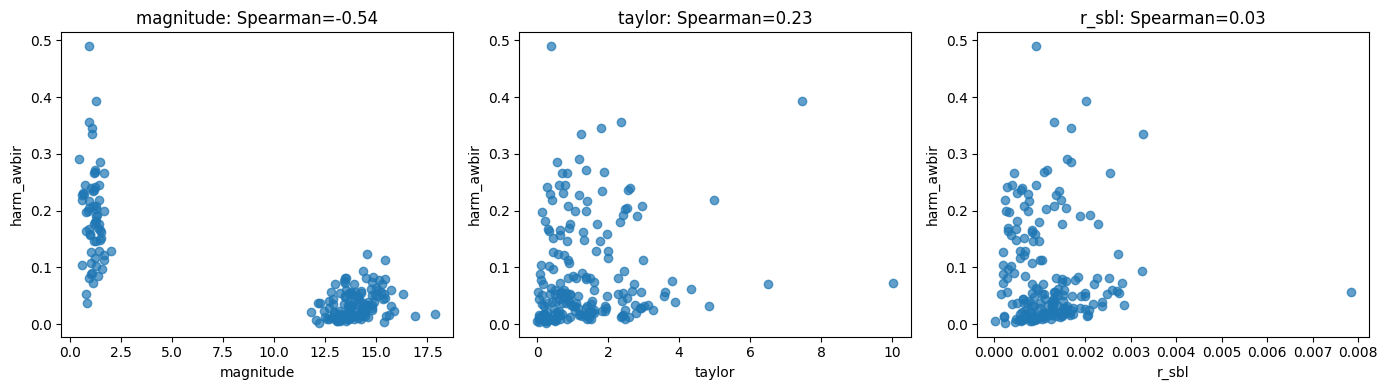

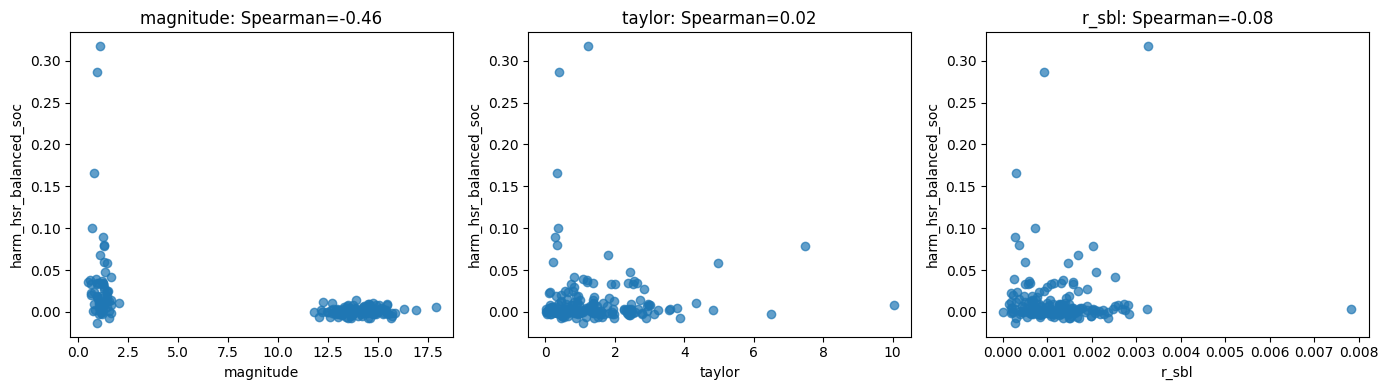

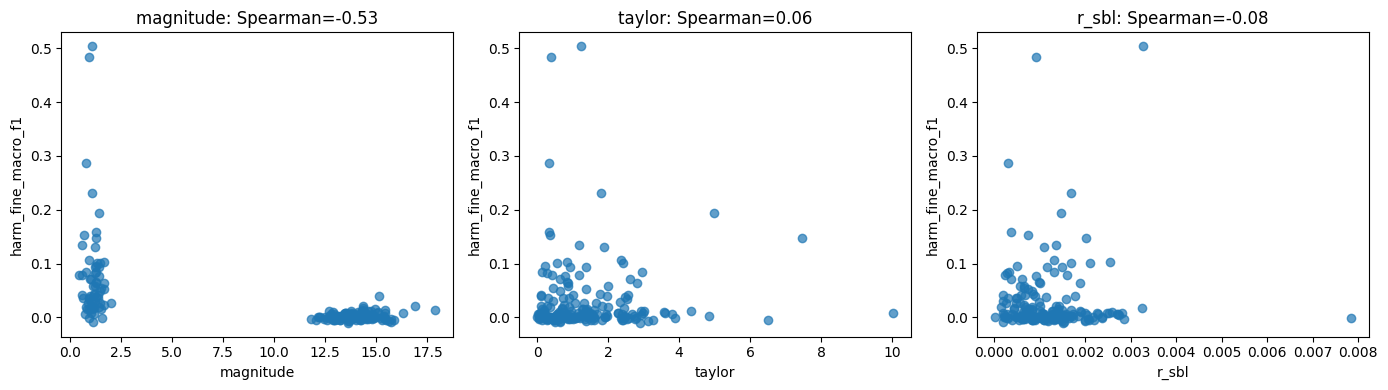

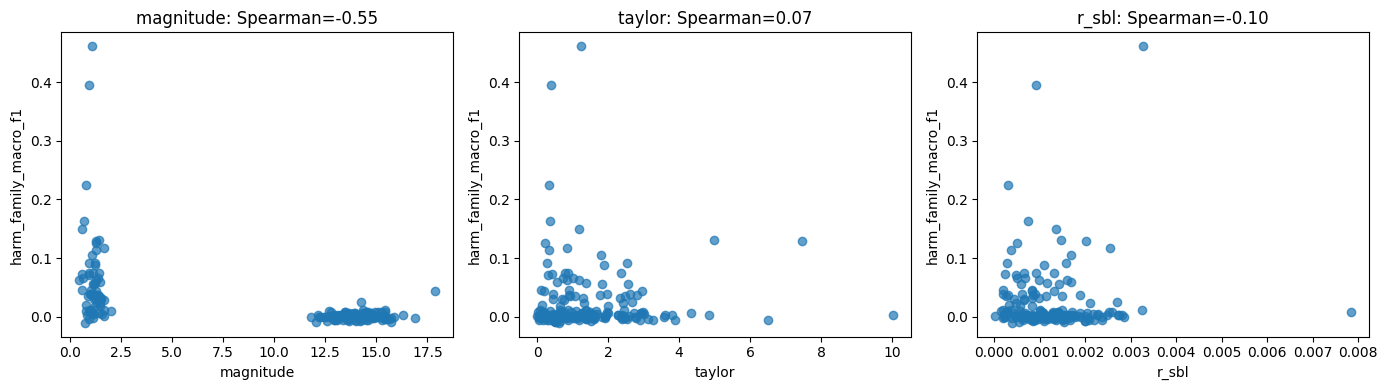

In [14]:
import matplotlib.pyplot as plt

for harm in harm_columns:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, score in zip(axes, ["magnitude", "taylor", "r_sbl"]):
        ax.scatter(analysis[score], analysis[harm], alpha=0.7)
        rho = validation[
            (validation["score"] == score) & (validation["harm"] == harm)
        ]["spearman"].iloc[0]
        ax.set_title(f"{score}: Spearman={rho:.2f}")
        ax.set_xlabel(score)
        ax.set_ylabel(harm)
    fig.tight_layout()
    safe_name = harm.replace("harm_", "")
    fig.savefig(OUT / f"score_vs_{safe_name}.png", dpi=250)
    plt.show()

## 8. Interpretation

- **Pass:** proceed to Notebook 17 and preserve this exact graph/score config.
- **Borderline:** repeat the score at 256/1,024 samples per class and inspect
  environment/cost aggregation before redesigning.
- **Fail:** do not hide the result. Revisit the edge weighting or test a
  second-order estimate before investing in full SABER training.

In [15]:
import subprocess
from src.saber.adapters import save_run_manifest

try:
    git_commit = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()
except Exception:
    git_commit = None

artefacts = [
    OUT / "group_scores_with_r_sbl.csv",
    OUT / "edge_group_leverage_long.csv",
    OUT / "single_group_causal_ablation.csv",
    OUT / "score_harm_validation.csv",
    OUT / "score_and_causal_harm.csv",
    OUT / "G1_score_gate.json",
]
save_run_manifest(
    OUT / "manifest.json",
    notebook="16_saber_boundary_leverage.ipynb",
    config=SABER_CFG,
    artifacts=artefacts,
    git_commit=git_commit,
)
print("G1 PASS" if gate_pass else "G1 DID NOT PASS")

G1 DID NOT PASS


In [16]:
%%bash
cd /content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression
cp ../.gitconfig /root/.gitconfig 2>/dev/null; cp ../.git-credentials /root/.git-credentials 2>/dev/null && chmod 600 /root/.git-credentials
jupyter nbconvert --ClearOutputPreprocessor.enabled=True --inplace notebooks/16_saber_boundary_leverage.ipynb
git add notebooks/16_saber_boundary_leverage.ipynb results/saber
git commit -m "NB16 G1 FAILED: R-SBL ~0 vs causal harm on all 4 outcomes; Fisher strongest (0.69 AWBIR, 0.51 F1) - harm predictable, first-order margin score + size normalization misranks layers (harm concentrates in conv.0, R-SBL top-20 mostly conv.3). Gate honored: no NB17 until score redesign"
git push origin saber-ids-method

[saber-ids-method 773b9da] NB16 G1 FAILED: R-SBL ~0 vs causal harm on all 4 outcomes; Fisher strongest (0.69 AWBIR, 0.51 F1) - harm predictable, first-order margin score + size normalization misranks layers (harm concentrates in conv.0, R-SBL top-20 mostly conv.3). Gate honored: no NB17 until score redesign
 16 files changed, 60441 insertions(+), 30 deletions(-)
 create mode 100644 results/saber/16_score_validation/G1_score_gate.json
 create mode 100644 results/saber/16_score_validation/edge_group_leverage_long.csv
 create mode 100644 results/saber/16_score_validation/group_scores_with_r_sbl.csv
 create mode 100644 results/saber/16_score_validation/manifest.json
 create mode 100644 results/saber/16_score_validation/sbl_scores_alert_fatigue.csv
 create mode 100644 results/saber/16_score_validation/sbl_scores_balanced_soc.csv
 create mode 100644 results/saber/16_score_validation/sbl_scores_miss_sensitive.csv
 create mode 100644 results/saber/16_score_validation/score_and_causal_harm.csv


[NbConvertApp] Converting notebook notebooks/16_saber_boundary_leverage.ipynb to notebook
[NbConvertApp] Writing 31837 bytes to notebooks/16_saber_boundary_leverage.ipynb
To https://github.com/anasbiswas1/iot-trust-compression.git
   29f4634..773b9da  saber-ids-method -> saber-ids-method


In [17]:
import pandas as pd
from pathlib import Path
from scipy.stats import spearmanr

R = Path("/content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression/results/saber/16_score_validation")
df = pd.read_csv(R / "score_and_causal_harm.csv")
print(df.columns.tolist())

harms  = ["harm_awbir", "harm_fine_macro_f1", "harm_family_macro_f1", "harm_hsr_balanced_soc"]
scores = [c for c in ["r_sbl", "fisher", "taylor", "magnitude"] if c in df.columns]

for layer in ["conv.0", "conv.3"]:
    sub = df[df["module_path"] == layer]
    print(f"\n== {layer} (n={len(sub)}) ==")
    for s in scores:
        row = [f"{h.replace('harm_',''):16s}{spearmanr(sub[s], sub[h]).correlation:+.2f}"
               for h in harms]
        print(f"{s:9s} | " + " | ".join(row))

['group_id', 'module_path', 'layer_index', 'channel_index', 'out_channels', 'in_channels', 'kernel_size', 'parameter_cost', 'flops_cost', 'batchnorm_path', 'downstream_path', 'downstream_kind', 'random', 'magnitude', 'taylor', 'fisher', 'bn_gamma', 'r_sbl', 'profile_min', 'profile_mean', 'profile_max', 'profile_aggregation', 'profile_cvar_q', 'harm_awbir', 'harm_hsr_balanced_soc', 'harm_fine_macro_f1', 'harm_family_macro_f1', 'harm_benign_false_alert', 'student_fine_macro_f1', 'student_family_macro_f1']

== conv.0 (n=64) ==
r_sbl     | awbir           +0.52 | fine_macro_f1   +0.43 | family_macro_f1 +0.32 | hsr_balanced_soc+0.28
fisher    | awbir           +0.30 | fine_macro_f1   +0.08 | family_macro_f1 +0.06 | hsr_balanced_soc+0.06
taylor    | awbir           +0.26 | fine_macro_f1   +0.04 | family_macro_f1 -0.02 | hsr_balanced_soc+0.02
magnitude | awbir           -0.11 | fine_macro_f1   +0.02 | family_macro_f1 -0.16 | hsr_balanced_soc-0.15

== conv.3 (n=128) ==
r_sbl     | awbir       

In [18]:
import pandas as pd
from pathlib import Path
R = Path("/content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression/results/saber/16_score_validation")
for f in ["edge_group_leverage_long.csv", "sbl_scores_balanced_soc.csv"]:
    df = pd.read_csv(R / f)
    print(f, df.shape)
    print(df.columns.tolist())
    print(df.head(3).to_string(), "\n")

edge_group_leverage_long.csv (58752, 14)
['edge_id', 'source_index', 'target_index', 'source_class', 'target_class', 'group_id', 'module_path', 'channel_index', 'edge_weight', 'n_examples', 'teacher_margin_mean', 'raw_boundary_leverage', 'weighted_boundary_leverage', 'cost_profile']
   edge_id  source_index  target_index      source_class       target_class      group_id module_path  channel_index  edge_weight  n_examples  teacher_margin_mean  raw_boundary_leverage  weighted_boundary_leverage    cost_profile
0        0             0            32  Backdoor_Malware  VulnerabilityScan  conv.0:out:0      conv.0              0     0.026752         482            -2.152769               0.452134                    0.012096  miss_sensitive
1        0             0            32  Backdoor_Malware  VulnerabilityScan  conv.0:out:1      conv.0              1     0.026752         482            -2.152769               1.080738                    0.028912  miss_sensitive
2        0             0  

selection n=96 ({'conv.3': 64, 'conv.0': 32}), holdout n=96 ({'conv.3': 64, 'conv.0': 32})

== selection half ==
 harm    harm_awbir  harm_family_macro_f1  harm_fine_macro_f1  harm_hsr_balanced_soc
score                                                                              
fisher       0.682                 0.446               0.487                  0.407
v_a          0.392                 0.252               0.290                  0.233
v_b          0.315                 0.250               0.298                  0.229
v_c          0.850                 0.611               0.676                  0.616
v_d          0.655                 0.428               0.472                  0.389

wins vs fisher: {'v_a': 0, 'v_b': 0, 'v_c': 4, 'v_d': 0} | mean advantage: {'v_a': -0.214, 'v_b': -0.233, 'v_c': 0.183, 'v_d': -0.02}
CHOSEN (frozen for confirmatory holdout): v_c

== holdout half (chosen = confirmatory, rest exploratory) ==
 harm       harm_awbir  harm_family_macro_f1  harm_fine

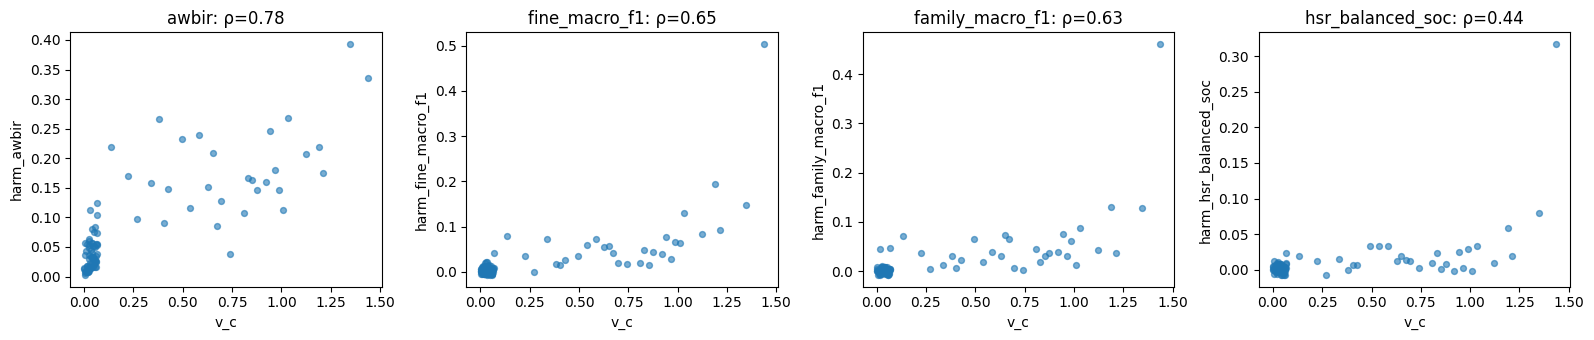


Saved to /content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression/results/saber/16b_score_v2


In [19]:
# NB16b: v2 score variants validated OFFLINE against the 192 cached causal harms.
# Pre-registered protocol (frozen before computation):
#   - Variants: V-A denormalized SBL; V-B Fisher-form (squared-leverage) SBL;
#     V-C within-layer semantic rank x layer-level Fisher scale;
#     V-D per-channel Fisher x within-layer semantic rank.
#   - Profile aggregation for V-A/V-B: mean over the 3 cost profiles (frozen choice).
#   - Selection on a stratified random HALF of groups (seed 0, stratified by layer);
#     winner = most harms (of 4) beating Fisher's Spearman on that half,
#     tie-break = highest mean Spearman advantage.
#   - Confirmatory gate G1b on the OTHER half only, chosen variant only:
#     PASS = beats Fisher on >=2 of 4 harms AND trails Fisher by >0.10 on none.
#   - All other variants' holdout numbers are reported as exploratory.
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

ROOT = Path("/content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression")
R16  = ROOT / "results/saber/16_score_validation"
OUT  = ROOT / "results/saber/16b_score_v2"
OUT.mkdir(parents=True, exist_ok=True)

HARMS = ["harm_awbir", "harm_fine_macro_f1", "harm_family_macro_f1", "harm_hsr_balanced_soc"]

df = pd.read_csv(R16 / "score_and_causal_harm.csv")
assert len(df) == 192 and df["group_id"].is_unique

# ---- V-A: denormalized SBL, mean over profiles ----
sbl = pd.concat([pd.read_csv(R16 / f"sbl_scores_{p}.csv")[["group_id", "sbl_raw"]]
                 for p in ["miss_sensitive", "balanced_soc", "alert_fatigue"]])
va = sbl.groupby("group_id")["sbl_raw"].mean().rename("v_a")

# ---- V-B: Fisher-form (edge_weight * leverage^2), mean over profiles ----
edges = pd.read_csv(R16 / "edge_group_leverage_long.csv")
vb = (edges.assign(sq=edges["edge_weight"] * edges["raw_boundary_leverage"] ** 2)
      .groupby(["group_id", "cost_profile"])["sq"].sum()
      .groupby("group_id").mean().rename("v_b"))

df = df.merge(va, on="group_id").merge(vb, on="group_id")
assert df[["v_a", "v_b"]].notna().all().all()

# ---- V-C / V-D: within-layer semantic rank, two layer-scale designs ----
df["sem_rank"] = df.groupby("module_path")["v_a"].rank(pct=True)
layer_fisher = df.groupby("module_path")["fisher"].mean()
df["v_c"] = df["sem_rank"] * df["module_path"].map(layer_fisher)
df["v_d"] = df["sem_rank"] * df["fisher"]

VARIANTS = ["v_a", "v_b", "v_c", "v_d"]

# ---- Stratified 50/50 split, seed 0 ----
rng = np.random.default_rng(0)
sel_mask = pd.Series(False, index=df.index)
for _, idx in df.groupby("module_path").groups.items():
    idx = np.array(list(idx))
    sel_mask.loc[rng.permutation(idx)[: len(idx) // 2]] = True
sel, hold = df[sel_mask], df[~sel_mask]
print(f"selection n={len(sel)} ({sel['module_path'].value_counts().to_dict()}), "
      f"holdout n={len(hold)} ({hold['module_path'].value_counts().to_dict()})")

def table(frame, scores):
    rows = []
    for s in scores:
        for h in HARMS:
            rows.append({"score": s, "harm": h,
                         "spearman": spearmanr(frame[s], frame[h]).correlation})
    return pd.DataFrame(rows)

# ---- Selection ----
sel_tab = table(sel, VARIANTS + ["fisher"]).pivot(index="score", columns="harm", values="spearman")
fisher_sel = sel_tab.loc["fisher"]
wins = (sel_tab.loc[VARIANTS] > fisher_sel).sum(axis=1)
adv  = (sel_tab.loc[VARIANTS] - fisher_sel).mean(axis=1)
chosen = wins.sort_values(ascending=False).index[
    np.argmax(adv.loc[wins == wins.max()].values)] if (wins == wins.max()).sum() > 1 else wins.idxmax()
print("\n== selection half ==\n", sel_tab.round(3).to_string())
print(f"\nwins vs fisher: {wins.to_dict()} | mean advantage: {adv.round(3).to_dict()}")
print(f"CHOSEN (frozen for confirmatory holdout): {chosen}")

# ---- Confirmatory holdout: chosen variant only ----
hold_tab = table(hold, VARIANTS + ["fisher", "taylor", "magnitude", "r_sbl"]) \
           .pivot(index="score", columns="harm", values="spearman")
fisher_hold, chosen_hold = hold_tab.loc["fisher"], hold_tab.loc[chosen]
n_won   = int((chosen_hold > fisher_hold).sum())
max_def = float((fisher_hold - chosen_hold).max())
passed  = bool(n_won >= 2 and max_def <= 0.10)
print("\n== holdout half (chosen = confirmatory, rest exploratory) ==\n",
      hold_tab.round(3).to_string())
print(f"\nG1b: chosen={chosen} | harms won vs fisher={n_won}/4 | "
      f"max deficit={max_def:.3f} | PASSED={passed}")

# ---- Persist ----
df[["group_id", "module_path", "channel_index"] + VARIANTS + ["sem_rank"]] \
    .to_csv(OUT / "v2_scores.csv", index=False)
sel_tab.to_csv(OUT / "v2_selection_report.csv")
hold_tab.to_csv(OUT / "v2_holdout_report.csv")
gate = {"gate": "G1b_score_v2_offline", "passed": passed, "chosen_variant": chosen,
        "protocol": "stratified half-split seed0; select-most-wins-vs-fisher; "
                    "confirm on holdout; pass = >=2/4 harms won and max deficit <=0.10",
        "harms_won": n_won, "max_deficit_vs_fisher": max_def,
        "holdout": {h: {"chosen": float(chosen_hold[h]), "fisher": float(fisher_hold[h])}
                    for h in HARMS}}
(OUT / "G1b_score_gate.json").write_text(json.dumps(gate, indent=2))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, h in zip(axes, HARMS):
    ax.scatter(hold[chosen], hold[h], alpha=0.6, s=18)
    ax.set_xlabel(chosen); ax.set_ylabel(h)
    ax.set_title(f"{h.replace('harm_','')}: ρ={spearmanr(hold[chosen], hold[h]).correlation:.2f}")
plt.tight_layout(); plt.savefig(OUT / "v2_holdout_scatter.png", dpi=120); plt.show()
print("\nSaved to", OUT)

In [21]:
import nbformat as nbf
from pathlib import Path

REPO = Path("/content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression")

CODE = r'''# NB16b: v2 score variants validated OFFLINE against the 192 cached causal harms.
# Pre-registered protocol (frozen before computation):
#   - Variants: V-A denormalized SBL; V-B Fisher-form (squared-leverage) SBL;
#     V-C within-layer semantic rank x layer-level Fisher scale;
#     V-D per-channel Fisher x within-layer semantic rank.
#   - Profile aggregation for V-A/V-B: mean over the 3 cost profiles (frozen choice).
#   - Selection on a stratified random HALF of groups (seed 0, stratified by layer);
#     winner = most harms (of 4) beating Fisher's Spearman on that half,
#     tie-break = highest mean Spearman advantage.
#   - Confirmatory gate G1b on the OTHER half only, chosen variant only:
#     PASS = beats Fisher on >=2 of 4 harms AND trails Fisher by >0.10 on none.
#   - All other variants' holdout numbers are reported as exploratory.
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

ROOT = Path("/content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression")
R16  = ROOT / "results/saber/16_score_validation"
OUT  = ROOT / "results/saber/16b_score_v2"
OUT.mkdir(parents=True, exist_ok=True)

HARMS = ["harm_awbir", "harm_fine_macro_f1", "harm_family_macro_f1", "harm_hsr_balanced_soc"]

df = pd.read_csv(R16 / "score_and_causal_harm.csv")
assert len(df) == 192 and df["group_id"].is_unique

sbl = pd.concat([pd.read_csv(R16 / f"sbl_scores_{p}.csv")[["group_id", "sbl_raw"]]
                 for p in ["miss_sensitive", "balanced_soc", "alert_fatigue"]])
va = sbl.groupby("group_id")["sbl_raw"].mean().rename("v_a")

edges = pd.read_csv(R16 / "edge_group_leverage_long.csv")
vb = (edges.assign(sq=edges["edge_weight"] * edges["raw_boundary_leverage"] ** 2)
      .groupby(["group_id", "cost_profile"])["sq"].sum()
      .groupby("group_id").mean().rename("v_b"))

df = df.merge(va, on="group_id").merge(vb, on="group_id")
assert df[["v_a", "v_b"]].notna().all().all()

df["sem_rank"] = df.groupby("module_path")["v_a"].rank(pct=True)
layer_fisher = df.groupby("module_path")["fisher"].mean()
df["v_c"] = df["sem_rank"] * df["module_path"].map(layer_fisher)
df["v_d"] = df["sem_rank"] * df["fisher"]

VARIANTS = ["v_a", "v_b", "v_c", "v_d"]

rng = np.random.default_rng(0)
sel_mask = pd.Series(False, index=df.index)
for _, idx in df.groupby("module_path").groups.items():
    idx = np.array(list(idx))
    sel_mask.loc[rng.permutation(idx)[: len(idx) // 2]] = True
sel, hold = df[sel_mask], df[~sel_mask]
print(f"selection n={len(sel)}, holdout n={len(hold)}")

def table(frame, scores):
    rows = []
    for s in scores:
        for h in HARMS:
            rows.append({"score": s, "harm": h,
                         "spearman": spearmanr(frame[s], frame[h]).correlation})
    return pd.DataFrame(rows)

sel_tab = table(sel, VARIANTS + ["fisher"]).pivot(index="score", columns="harm", values="spearman")
fisher_sel = sel_tab.loc["fisher"]
wins = (sel_tab.loc[VARIANTS] > fisher_sel).sum(axis=1)
adv  = (sel_tab.loc[VARIANTS] - fisher_sel).mean(axis=1)
chosen = wins.sort_values(ascending=False).index[
    np.argmax(adv.loc[wins == wins.max()].values)] if (wins == wins.max()).sum() > 1 else wins.idxmax()
print("\n== selection half ==\n", sel_tab.round(3).to_string())
print(f"\nwins vs fisher: {wins.to_dict()} | mean advantage: {adv.round(3).to_dict()}")
print(f"CHOSEN: {chosen}")

hold_tab = table(hold, VARIANTS + ["fisher", "taylor", "magnitude", "r_sbl"]) \
           .pivot(index="score", columns="harm", values="spearman")
fisher_hold, chosen_hold = hold_tab.loc["fisher"], hold_tab.loc[chosen]
n_won   = int((chosen_hold > fisher_hold).sum())
max_def = float((fisher_hold - chosen_hold).max())
passed  = bool(n_won >= 2 and max_def <= 0.10)
print("\n== holdout half ==\n", hold_tab.round(3).to_string())
print(f"\nG1b: chosen={chosen} | harms won={n_won}/4 | max deficit={max_def:.3f} | PASSED={passed}")

df[["group_id", "module_path", "channel_index"] + VARIANTS + ["sem_rank"]] \
    .to_csv(OUT / "v2_scores.csv", index=False)
sel_tab.to_csv(OUT / "v2_selection_report.csv")
hold_tab.to_csv(OUT / "v2_holdout_report.csv")
gate = {"gate": "G1b_score_v2_offline", "passed": passed, "chosen_variant": chosen,
        "protocol": "stratified half-split seed0; select-most-wins-vs-fisher; "
                    "confirm on holdout; pass = >=2/4 harms won and max deficit <=0.10",
        "harms_won": n_won, "max_deficit_vs_fisher": max_def,
        "holdout": {h: {"chosen": float(chosen_hold[h]), "fisher": float(fisher_hold[h])}
                    for h in HARMS}}
(OUT / "G1b_score_gate.json").write_text(json.dumps(gate, indent=2))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, h in zip(axes, HARMS):
    ax.scatter(hold[chosen], hold[h], alpha=0.6, s=18)
    ax.set_xlabel(chosen); ax.set_ylabel(h)
    ax.set_title(f"{h.replace('harm_','')}: rho={spearmanr(hold[chosen], hold[h]).correlation:.2f}")
plt.tight_layout(); plt.savefig(OUT / "v2_holdout_scatter.png", dpi=120); plt.show()
print("\nSaved to", OUT)
'''

nb = nbf.v4.new_notebook()
nb.cells = [
    nbf.v4.new_markdown_cell(
        "# Notebook 16b — Offline v2 score validation (G1b)\n\n"
        "Validates pre-registered v2 saliency variants against the 192 cached causal "
        "channel-ablation harms from Notebook 16. Fully offline: no GPU, no data "
        "loading, no re-ablation. Protocol frozen before computation; selection and "
        "confirmation use disjoint stratified halves (seed 0).\n\n"
        "**Recorded outcome of the archived run:** chosen variant `v_c` "
        "(Fisher layer mass x within-layer ASVG leverage rank); G1b PASSED 4/4 "
        "harms vs Fisher on the holdout (AWBIR 0.782 vs 0.711), max deficit -0.045."),
    nbf.v4.new_code_cell(CODE),
]
out = REPO / "notebooks/16b_score_v2_offline_validation.ipynb"
nbf.write(nb, out)
print("written:", out, out.stat().st_size, "bytes")

written: /content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression/notebooks/16b_score_v2_offline_validation.ipynb 7063 bytes


In [22]:
%%bash
cd /content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression
git add notebooks/16b_score_v2_offline_validation.ipynb results/saber/16b_score_v2
git commit -m "NB16b G1b PASSED: v2 score V-C (Fisher layer mass x within-layer ASVG leverage rank) beats Fisher 4/4 harms on pre-registered holdout (AWBIR 0.78 vs 0.71); stratified half-split seed0 select/confirm protocol; caveats: 2-layer arch limits layer-scale test, screening-strength n"
git push origin saber-ids-method
git log --oneline -1

[saber-ids-method fc947ab] NB16b G1b PASSED: v2 score V-C (Fisher layer mass x within-layer ASVG leverage rank) beats Fisher 4/4 harms on pre-registered holdout (AWBIR 0.78 vs 0.71); stratified half-split seed0 select/confirm protocol; caveats: 2-layer arch limits layer-scale test, screening-strength n
 6 files changed, 364 insertions(+)
 create mode 100644 notebooks/16b_score_v2_offline_validation.ipynb
 create mode 100644 results/saber/16b_score_v2/G1b_score_gate.json
 create mode 100644 results/saber/16b_score_v2/v2_holdout_report.csv
 create mode 100644 results/saber/16b_score_v2/v2_holdout_scatter.png
 create mode 100644 results/saber/16b_score_v2/v2_scores.csv
 create mode 100644 results/saber/16b_score_v2/v2_selection_report.csv
fc947ab NB16b G1b PASSED: v2 score V-C (Fisher layer mass x within-layer ASVG leverage rank) beats Fisher 4/4 harms on pre-registered holdout (AWBIR 0.78 vs 0.71); stratified half-split seed0 select/confirm protocol; caveats: 2-layer arch limits layer-sc

To https://github.com/anasbiswas1/iot-trust-compression.git
   773b9da..fc947ab  saber-ids-method -> saber-ids-method
